# Who Are the Main Characters in the Gospel of Mark? 👤

If you read the Gospel of Mark, you quickly notice it's an action-packed story. But who are the people driving that action? Who gets mentioned the most?

In this notebook, we use Natural Language Processing (NLP) to automatically read through the entire Greek text of Mark and count every time a specific person or place is mentioned. This helps us objectively see who the "main characters" are, right down to the numbers!

We will:
1. Use an AI model trained on Ancient Greek to find all the **Proper Nouns** (names of people and places).
2. Translate those Greek names into English using a biblical dictionary.
3. Graph the Top 20 most frequently mentioned people and places.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="thinc.shims.pytorch")

import spacy
import collections
import re
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt

# Load the transformer model for Ancient Greek
print("Loading Greek NLP model (this might take a moment)...")
nlp = spacy.load("grc_odycy_joint_trf")

Loading Greek NLP model (this might take a moment)...


## 1. Reading and Processing the Text

First, we load the original Greek text of the Gospel of Mark. 
Then, we hand it over to our AI model (`nlp`), which acts like a highly-trained Greek scholar. It reads every word and tags it with its grammatical role—identifying whether a word is a verb, a regular noun, or a **Proper Noun** (like a name).

In [2]:
# Read the Greek text of Mark
with open("data/NT/Greek/Mark-greek.txt", "r", encoding="utf-8") as f:
    text = f.read()

# Remove verse numbers so they don't confuse the text analyzer
text = re.sub(r'\d+', ' ', text)

print("Processing text...")
doc = nlp(text)
print(f"Successfully analyzed {len(doc)} words!")

Processing text...
Successfully analyzed 13729 words!


## 2. Finding the Names and Translating Them

Now that the text is analyzed, we will filter out everything except the names (`PROPN` in grammatical terms).

Because the names are in Ancient Greek (e.g., Ἰησοῦς, Πέτρος), we will use a special dictionary file from the STEPBible project to map them to their familiar English equivalents (Jesus, Peter).

In [3]:
propn_freq = collections.Counter()

for t in doc:
    # Sometimes the model tags Proper Nouns as regular NOUNs, so we also check for Capitalized words
    if t.pos_ in ["PROPN", "NOUN"] and t.text and t.text[0].isupper():
        propn_freq[t.lemma_] += 1
    elif t.pos_ == "PROPN":
        propn_freq[t.lemma_] += 1

# A helper function to remove Greek accents to match our dictionary
def remove_accents(text):
    text = text.replace("(", "").replace(")", "").replace("2", "")
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn').lower()

# Load the STEPBible dictionary to translate Greek names to English
lexicon_path = "STEPBible-Data/Lexicons/TBESG - Translators Brief lexicon of Extended Strongs for Greek - STEPBible.org CC BY.txt"
greek_to_english = {}

with open(lexicon_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith("G") and "\t" in line:
            parts = line.split("\t")
            if len(parts) >= 7:
                greek_words = parts[3].strip().split(",")
                english_gloss = parts[6].strip()
                for gw in greek_words:
                    clean_gw = remove_accents(gw.strip())
                    if clean_gw not in greek_to_english:
                        greek_to_english[clean_gw] = english_gloss

# Add a couple of manual translations that might be missing or alternate spellings
greek_to_english["βηθσαιδαν"] = "Bethsaida"
greek_to_english["ιεροσολυμων"] = "Jerusalem"

# Match the counted Greek names to their English translations
names_data = []
for greek_name, freq in propn_freq.items():
    norm_name = remove_accents(greek_name)
    english_name = greek_to_english.get(norm_name, "Unknown")
    
    # We combine the English and Greek names for our chart
    display_name = f"{english_name} ({greek_name})"
    names_data.append({"Name": display_name, "Frequency": freq})

# Convert our list to a pandas DataFrame for easy sorting and plotting
df_names = pd.DataFrame(names_data)
# Group by Name to combine any alternate spellings that translated to the same English name
df_names = df_names.groupby("Name", as_index=False).sum()
df_names = df_names.sort_values(by="Frequency", ascending=False).reset_index(drop=True)

print("Top 5 Most Mentioned Names:")
print(df_names.head())

Top 5 Most Mentioned Names:
                   Name  Frequency
0        Jesus (ἰησοῦς)         82
1      John (ἰωάν(ν)ης)         26
2        Peter (πέτρος)         20
3       James (ἰάκωβος)         15
4  Pharisee (φαρισαῖος)         12


## 3. Visualizing the Top 20 Characters and Places

Let's build a bar chart to easily see the most dominant figures in Mark's narrative. 
*Spoiler alert: The Gospel is very much centered on Jesus!*

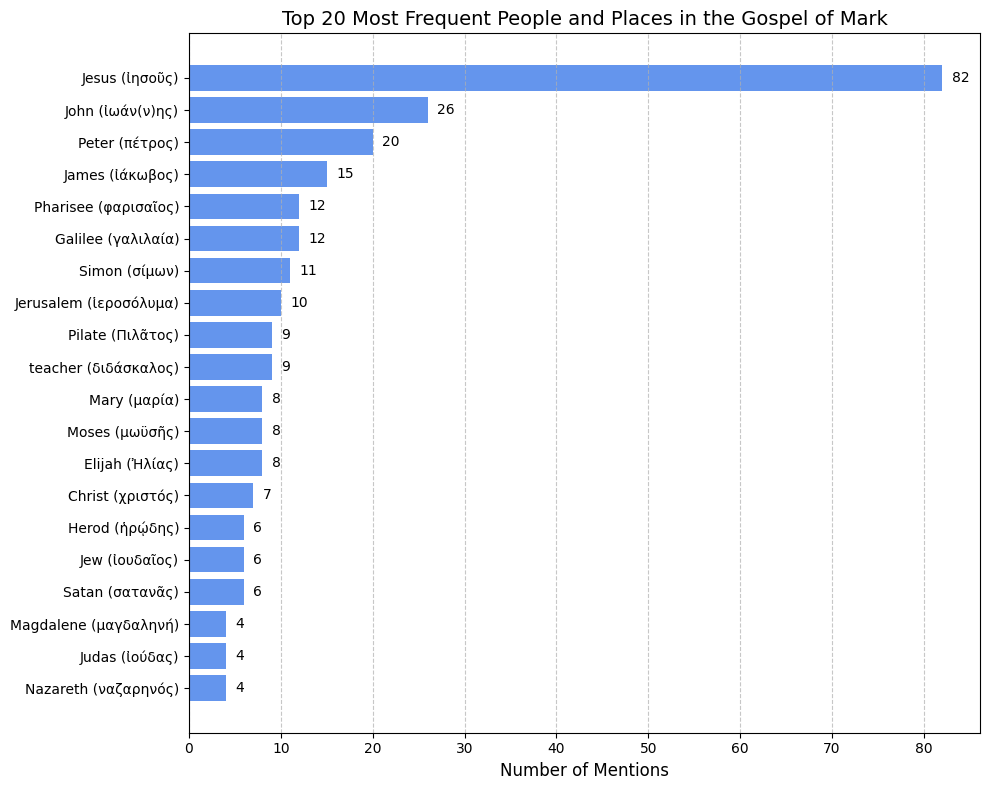

In [4]:
# Take the top 20 most frequent names
top_20 = df_names.head(20).copy()

# Reverse the order so the highest frequency is at the top of the horizontal bar chart
top_20 = top_20.iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top_20["Name"], top_20["Frequency"], color="cornflowerblue")
plt.xlabel("Number of Mentions", fontsize=12)
plt.title("Top 20 Most Frequent People and Places in the Gospel of Mark", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the exact numbers to the end of the bars
for index, value in enumerate(top_20["Frequency"]):
    plt.text(value + 1, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()